# Complement Naive Bayes Classifier for Fake Review Detection

## 1. Introduction
Complement Naive Bayes (CNB) is an adaptation of the standard Multinomial Naive Bayes algorithm that is particularly suited for imbalanced datasets. Although our dataset is balanced, CNB often outperforms Multinomial NB on text classification tasks.

In this notebook, we use the precomputed TF-IDF features to train and optimize a Complement Naive Bayes model.

---


In [7]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Constants
DATA_PATH = '../data/processed/X_tfidf.pkl'
LABEL_PATH = '../data/processed/y.pkl'
MODEL_DIR = '../data/processed'
SEED = 42


## 2. Loading and Splitting Data
We load the precomputed TF-IDF features and labels. We split the data into training (80%) and testing (20%) sets, using **stratification** to maintain the class balance.


In [8]:
X = joblib.load(DATA_PATH)
y = joblib.load(LABEL_PATH)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Data loaded and split:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Data loaded and split:
Training samples: 32345
Testing samples: 8087


## 3. Hyperparameter Tuning
For Complement Naive Bayes, we tune:
- **`alpha`**: Smoothing parameter.
- **`fit_prior`**: Whether to learn class prior probabilities or not.

We use `GridSearchCV` with 5-fold cross-validation.


In [9]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'fit_prior': [True, False]
}

print("Starting Grid Search...")
grid_search = GridSearchCV(
    ComplementNB(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_nb_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")


Starting Grid Search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'alpha': 0.01, 'fit_prior': True}
Best Cross-Validation Score: 0.8823


## 4. Evaluation
We evaluate the best model on the test set.


In [10]:
y_pred = best_nb_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Original (OR)', 'Computer Generated (CG)']))


Test Accuracy: 0.8852479287745765

Classification Report:

                         precision    recall  f1-score   support

          Original (OR)       0.87      0.91      0.89      4044
Computer Generated (CG)       0.91      0.86      0.88      4043

               accuracy                           0.89      8087
              macro avg       0.89      0.89      0.89      8087
           weighted avg       0.89      0.89      0.89      8087



## 5. Visualizing Results

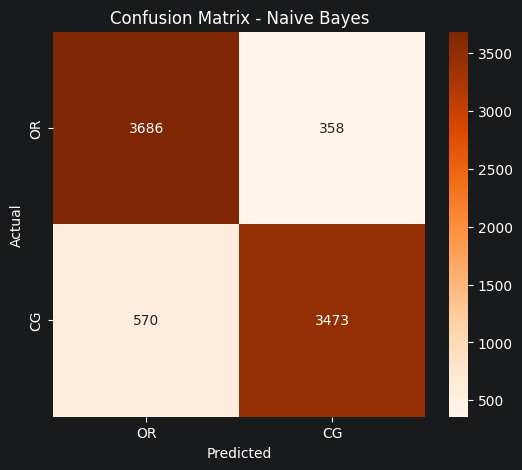

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['OR', 'CG'], yticklabels=['OR', 'CG'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()


## 6. Saving the Model

In [12]:
model_filename = os.path.join(MODEL_DIR, 'nb_model.pkl')
joblib.dump(best_nb_model, model_filename)
print(f"Model saved to: {model_filename}")

Model saved to: ../data/processed\nb_model.pkl
